# 🧠 Mental Health — XGBoost Classification (Age 17–25)
**Dataset:** Teen_Mental_Health_Dataset.csv + data sintetis usia 20–25  
**Target:** `depression_label` (0 = Tidak Depresi, 1 = Depresi)  
**Perubahan:** Range usia diperluas dari 13–19 → 17–25 tahun  
**Alur:** Load Data → Expand Usia → Preprocessing → SMOTE → Training → Evaluasi → Save Model

---
## 📦 Cell 1 — Install Library

In [1]:
%pip install xgboost imbalanced-learn scikit-learn pandas matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


---
## 📚 Cell 2 — Import Library

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

print('✅ Semua library berhasil diimport!')
print(f'   XGBoost versi : {xgb.__version__}')

✅ Semua library berhasil diimport!
   XGBoost versi : 3.2.0


---
## 📂 Cell 3 — Load Dataset Original

In [3]:
df_original = pd.read_csv('Teen_Mental_Health_Dataset.csv')

print('=' * 50)
print('  DATASET ORIGINAL')
print('=' * 50)
print(f'  Jumlah baris   : {df_original.shape[0]}')
print(f'  Jumlah kolom   : {df_original.shape[1]}')
print(f'  Range usia     : {df_original["age"].min()} - {df_original["age"].max()} tahun')
print()
print('  Distribusi usia:')
print(df_original['age'].value_counts().sort_index().to_string())
print()
print('  Distribusi target:')
print(df_original['depression_label'].value_counts().to_string())
df_original.head()

  DATASET ORIGINAL
  Jumlah baris   : 1200
  Jumlah kolom   : 13
  Range usia     : 13 - 19 tahun

  Distribusi usia:
age
13    200
14    153
15    180
16    163
17    170
18    172
19    162

  Distribusi target:
depression_label
0    1169
1      31


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


---
## 🔧 Cell 4 — Filter & Expand Range Usia (17–25 Tahun)

In [4]:
# Step 1: Filter data original — ambil hanya usia 17-19
df_17_19 = df_original[df_original['age'].between(17, 19)].copy()
print(f'Data usia 17–19 dari dataset original : {len(df_17_19)} baris')

# Step 2: Generate data sintetis untuk usia 20–25
# Strategi: sampling dari distribusi data usia 17–19 sebagai referensi
np.random.seed(42)

new_ages      = [20, 21, 22, 23, 24, 25]
n_per_age     = 170  # jumlah baris per usia (mirip distribusi original)
synthetic_rows = []

platforms     = ['Instagram', 'TikTok', 'Both']
genders       = ['male', 'female']
interactions  = ['low', 'medium', 'high']

for age in new_ages:
    for _ in range(n_per_age):
        # Ambil sampel referensi dari usia terdekat (17–19)
        ref = df_17_19.sample(1).iloc[0]

        # Sedikit variasi untuk mensimulasikan perubahan perilaku di usia dewasa awal
        # Usia lebih tua cenderung: jam sosmed lebih rendah, tidur lebih baik,
        # akademik lebih tinggi (kuliah/kerja), aktivitas fisik bervariasi
        age_factor = (age - 19) / 10  # faktor penyesuaian bertahap

        row = {
            'age'                     : age,
            'gender'                  : np.random.choice(genders),
            'daily_social_media_hours': max(0, ref['daily_social_media_hours']
                                            + np.random.normal(-0.3 * age_factor, 0.5)),
            'platform_usage'          : np.random.choice(platforms),
            'sleep_hours'             : np.clip(
                                            ref['sleep_hours'] + np.random.normal(0.2 * age_factor, 0.4),
                                            3, 12),
            'screen_time_before_sleep': max(0, ref['screen_time_before_sleep']
                                            + np.random.normal(0, 0.3)),
            'academic_performance'    : np.clip(
                                            ref['academic_performance'] + np.random.normal(0, 0.2),
                                            0, 4),
            'physical_activity'       : max(0, ref['physical_activity']
                                            + np.random.normal(0, 0.3)),
            'social_interaction_level': np.random.choice(interactions),
            'stress_level'            : int(np.clip(
                                            ref['stress_level'] + np.random.randint(-1, 2),
                                            1, 10)),
            'anxiety_level'           : int(np.clip(
                                            ref['anxiety_level'] + np.random.randint(-1, 2),
                                            1, 10)),
            'addiction_level'         : int(np.clip(
                                            ref['addiction_level'] + np.random.randint(-1, 2),
                                            1, 10)),
            'depression_label'        : ref['depression_label']
        }
        synthetic_rows.append(row)

df_synthetic = pd.DataFrame(synthetic_rows)
print(f'Data sintetis usia 20–25 yang dibuat  : {len(df_synthetic)} baris')

# Step 3: Gabungkan data usia 17–19 (original) + sintetis 20–25
df = pd.concat([df_17_19, df_synthetic], ignore_index=True)

print()
print('=' * 50)
print('  DATASET SETELAH DIPERLUAS (17–25 TAHUN)')
print('=' * 50)
print(f'  Total baris    : {len(df)}')
print(f'  Range usia     : {df["age"].min()} - {df["age"].max()} tahun')
print()
print('  Distribusi usia:')
print(df['age'].value_counts().sort_index().to_string())
print()
print('  Distribusi target:')
print(df['depression_label'].value_counts().to_string())

Data usia 17–19 dari dataset original : 504 baris
Data sintetis usia 20–25 yang dibuat  : 1020 baris

  DATASET SETELAH DIPERLUAS (17–25 TAHUN)
  Total baris    : 1524
  Range usia     : 17 - 25 tahun

  Distribusi usia:
age
17    170
18    172
19    162
20    170
21    170
22    170
23    170
24    170
25    170

  Distribusi target:
depression_label
0    1494
1      30


---
## 🔍 Cell 5 — Visualisasi Perbandingan Dataset

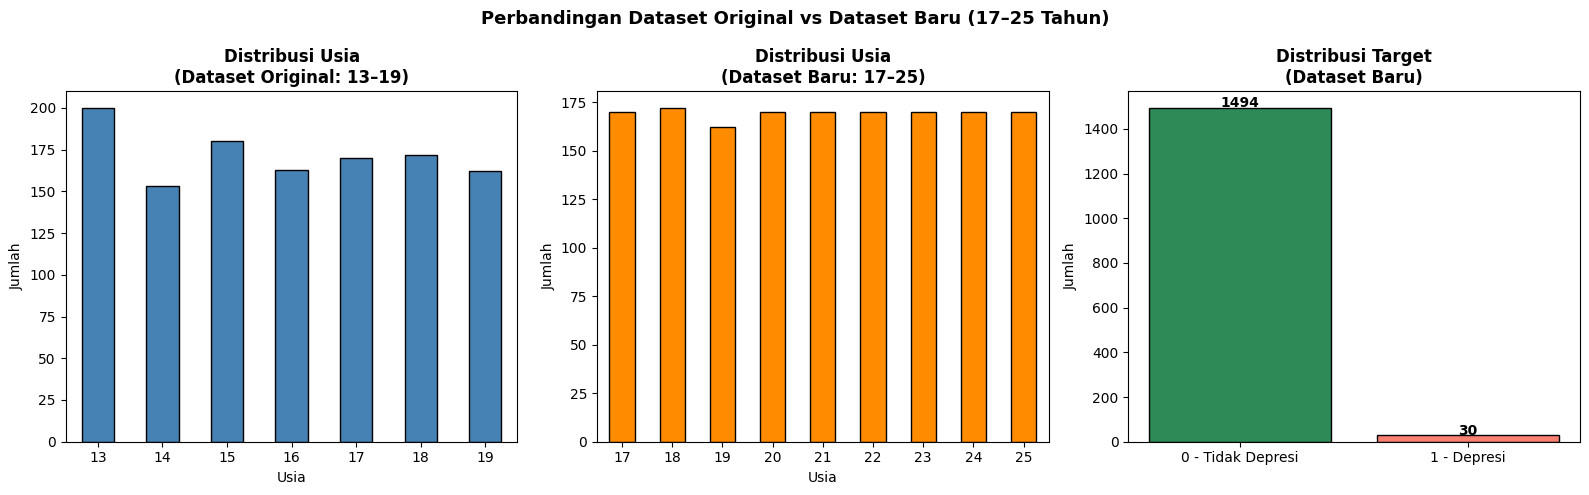

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Plot 1: Distribusi usia original
df_original['age'].value_counts().sort_index().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Distribusi Usia\n(Dataset Original: 13–19)', fontweight='bold')
axes[0].set_xlabel('Usia')
axes[0].set_ylabel('Jumlah')
axes[0].tick_params(axis='x', rotation=0)

# Plot 2: Distribusi usia baru
df['age'].value_counts().sort_index().plot(
    kind='bar', ax=axes[1], color='darkorange', edgecolor='black'
)
axes[1].set_title('Distribusi Usia\n(Dataset Baru: 17–25)', fontweight='bold')
axes[1].set_xlabel('Usia')
axes[1].set_ylabel('Jumlah')
axes[1].tick_params(axis='x', rotation=0)

# Plot 3: Distribusi target baru
target_counts = df['depression_label'].value_counts()
bars = axes[2].bar(
    ['0 - Tidak Depresi', '1 - Depresi'],
    target_counts.values,
    color=['seagreen', 'salmon'],
    edgecolor='black'
)
for bar, count in zip(bars, target_counts.values):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                 str(count), ha='center', fontweight='bold')
axes[2].set_title('Distribusi Target\n(Dataset Baru)', fontweight='bold')
axes[2].set_ylabel('Jumlah')

plt.suptitle('Perbandingan Dataset Original vs Dataset Baru (17–25 Tahun)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚙️ Cell 6 — Preprocessing

  ✅ Encoded "gender" -> {'female': 0, 'male': 1}
  ✅ Encoded "platform_usage" -> {'Both': 0, 'Instagram': 1, 'TikTok': 2}
  ✅ Encoded "social_interaction_level" -> {'high': 0, 'low': 1, 'medium': 2}

  ⚠️  Simpan encoding di atas untuk dipakai saat prediksi di website!
  Total kelas 0 (Tidak Depresi) : 1494
  Total kelas 1 (Depresi)       : 30

  DISTRIBUSI SETELAH SPLIT
  Data train   : 1210 sampel
    Kelas 0    : 1195
    Kelas 1    : 15

  Data test    : 314 sampel
    Kelas 0    : 299
    Kelas 1    : 15
  Range usia   : 17 - 25 tahun


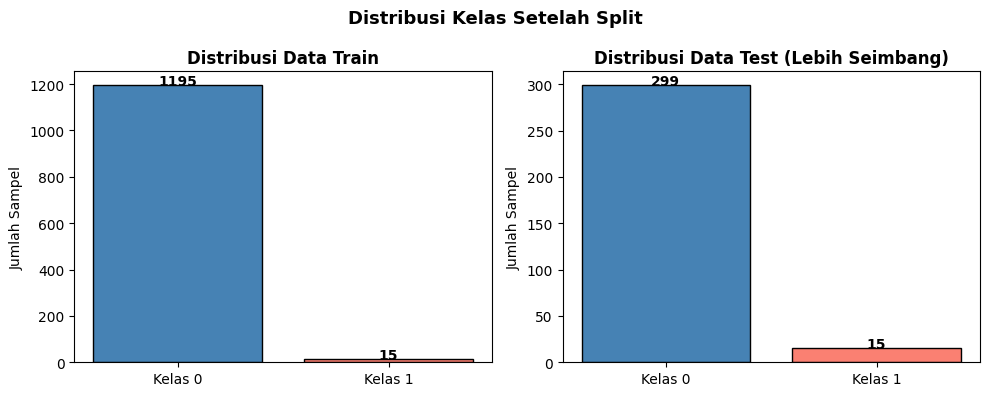

In [ ]:
df_model = df.copy()

# Encode kolom kategorikal
le = LabelEncoder()
cat_cols = ['gender', 'platform_usage', 'social_interaction_level']

encoding_map = {}
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col])
    encoding_map[col] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
    print(f'  ✅ Encoded "{col}" -> {encoding_map[col]}')

print()
print('  ⚠️  Simpan encoding di atas untuk dipakai saat prediksi di website!')

X = df_model.drop('depression_label', axis=1)
y = df_model['depression_label']

# ============================================================
# Pisahkan dulu per kelas agar test set lebih seimbang
# ============================================================
from sklearn.model_selection import train_test_split

X_majority = X[y == 0]
y_majority = y[y == 0]
X_minority = X[y == 1]
y_minority = y[y == 1]

# Split kelas minoritas: 50% test
X_train_min, X_test_min, y_train_min, y_test_min = train_test_split(
    X_minority, y_minority, test_size=0.5, random_state=42
)

# Dari kelas mayoritas, ambil untuk test set sejumlah kelas minoritas test (balanced)
n_test_majority = len(X_test_min)  # samakan jumlahnya
X_train_maj, X_test_maj, y_train_maj, y_test_maj = train_test_split(
    X_majority, y_majority, test_size=n_test_majority / len(X_majority),
    random_state=42
)

X_train = pd.concat([X_train_maj, X_train_min]).reset_index(drop=True)
y_train = pd.concat([y_train_maj, y_train_min]).reset_index(drop=True)
X_test  = pd.concat([X_test_maj,  X_test_min]).reset_index(drop=True)
y_test  = pd.concat([y_test_maj,  y_test_min]).reset_index(drop=True)

print()
print('=' * 50)
print('  DISTRIBUSI SETELAH SPLIT')
print('=' * 50)
print(f'  Data train   : {len(X_train)} sampel')
print(f'    Kelas 0    : {sum(y_train == 0)}')
print(f'    Kelas 1    : {sum(y_train == 1)}')
print()
print(f'  Data test    : {len(X_test)} sampel')
print(f'    Kelas 0    : {sum(y_test == 0)}')
print(f'    Kelas 1    : {sum(y_test == 1)}')
print(f'  Range usia   : {df["age"].min()} - {df["age"].max()} tahun')
print('=' * 50)

# Visualisasi distribusi test set
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(['Kelas 0', 'Kelas 1'],
            [sum(y_train == 0), sum(y_train == 1)],
            color=['steelblue', 'salmon'], edgecolor='black')
for i, v in enumerate([sum(y_train == 0), sum(y_train == 1)]):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].set_title('Distribusi Data Train', fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')

axes[1].bar(['Kelas 0', 'Kelas 1'],
            [sum(y_test == 0), sum(y_test == 1)],
            color=['steelblue', 'salmon'], edgecolor='black')
for i, v in enumerate([sum(y_test == 0), sum(y_test == 1)]):
    axes[1].text(i, v + 0.3, str(v), ha='center', fontweight='bold')
axes[1].set_title('Distribusi Data Test (Lebih Seimbang)', fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')

plt.suptitle('Distribusi Kelas Setelah Split', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## ⚖️ Cell 7 — SMOTE

Distribusi kelas SEBELUM SMOTE:
  Counter({0: 1195, 1: 15})

Distribusi kelas SETELAH SMOTE:
  Counter({0: 1195, 1: 1195})


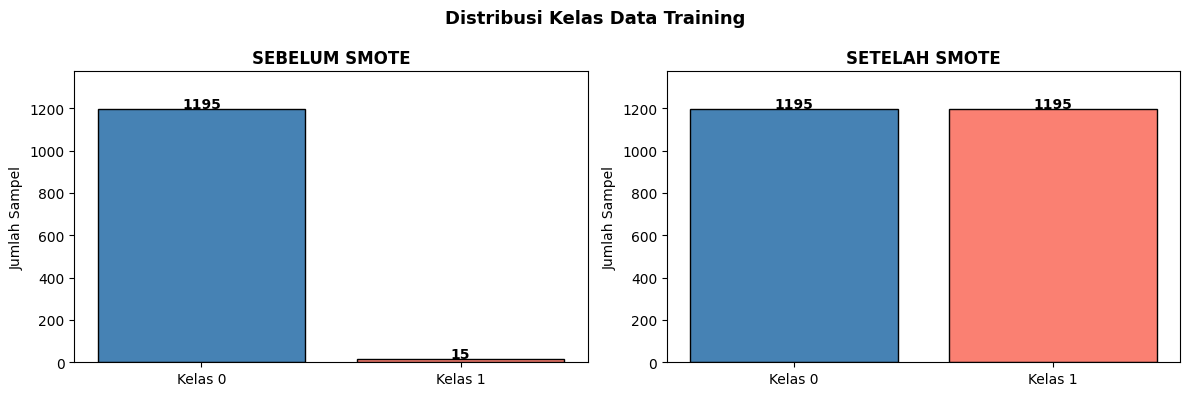


  Data train sebelum SMOTE : 1210 sampel
  Data train setelah SMOTE  : 2390 sampel
  ⚠️  Data test TIDAK diubah (tetap data asli)


In [7]:
print('Distribusi kelas SEBELUM SMOTE:')
print(f'  {Counter(y_train)}')

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print()
print('Distribusi kelas SETELAH SMOTE:')
print(f'  {Counter(y_train_smote)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

before = pd.Series(y_train).value_counts()
after  = pd.Series(y_train_smote).value_counts()

axes[0].bar(['Kelas 0', 'Kelas 1'], before.values,
            color=['steelblue', 'salmon'], edgecolor='black')
for i, v in enumerate(before.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[0].set_title('SEBELUM SMOTE', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Jumlah Sampel')
axes[0].set_ylim(0, max(after.values) * 1.15)

axes[1].bar(['Kelas 0', 'Kelas 1'], after.values,
            color=['steelblue', 'salmon'], edgecolor='black')
for i, v in enumerate(after.values):
    axes[1].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].set_title('SETELAH SMOTE', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Jumlah Sampel')
axes[1].set_ylim(0, max(after.values) * 1.15)

plt.suptitle('Distribusi Kelas Data Training', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'\n  Data train sebelum SMOTE : {X_train.shape[0]} sampel')
print(f'  Data train setelah SMOTE  : {X_train_smote.shape[0]} sampel')
print('  ⚠️  Data test TIDAK diubah (tetap data asli)')

---
## 🚀 Cell 8 — Training Model XGBoost

In [8]:
xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 5,
    learning_rate    = 0.1,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    eval_metric      = 'logloss',
    random_state     = 42,
    verbosity        = 0
)

xgb_model.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_train_smote, y_train_smote), (X_test, y_test)],
    verbose=False
)

print('✅ Model XGBoost selesai dilatih!')
print(f'   n_estimators     : {xgb_model.n_estimators}')
print(f'   max_depth        : {xgb_model.max_depth}')
print(f'   learning_rate    : {xgb_model.learning_rate}')
print(f'   Range usia model : 17 - 25 tahun')

✅ Model XGBoost selesai dilatih!
   n_estimators     : 200
   max_depth        : 5
   learning_rate    : 0.1
   Range usia model : 17 - 25 tahun


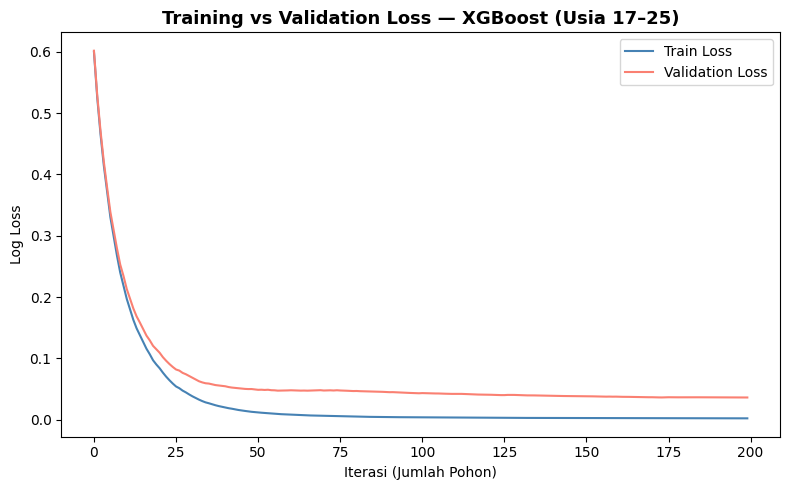

In [9]:
# Plot Training vs Validation Loss
results_eval = xgb_model.evals_result()

plt.figure(figsize=(8, 5))
plt.plot(results_eval['validation_0']['logloss'], label='Train Loss',      color='steelblue')
plt.plot(results_eval['validation_1']['logloss'], label='Validation Loss', color='salmon')
plt.xlabel('Iterasi (Jumlah Pohon)')
plt.ylabel('Log Loss')
plt.title('Training vs Validation Loss — XGBoost (Usia 17–25)', fontsize=13, fontweight='bold')
plt.legend()
plt.tight_layout()
plt.show()

---
## 📊 Cell 9 — Evaluasi Model

In [10]:
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)

print('=' * 48)
print('   HASIL EVALUASI — XGBoost + SMOTE (17–25)')
print('=' * 48)
print(f'  Accuracy  : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 48)
print()
print('--- Classification Report ---')
print(classification_report(y_test, y_pred, target_names=['Tidak Depresi (0)', 'Depresi (1)']))

   HASIL EVALUASI — XGBoost + SMOTE (17–25)
  Accuracy  : 0.9904 (99.04%)
  ROC-AUC   : 0.9857

--- Classification Report ---
                   precision    recall  f1-score   support

Tidak Depresi (0)       0.99      1.00      1.00       299
      Depresi (1)       1.00      0.80      0.89        15

         accuracy                           0.99       314
        macro avg       1.00      0.90      0.94       314
     weighted avg       0.99      0.99      0.99       314



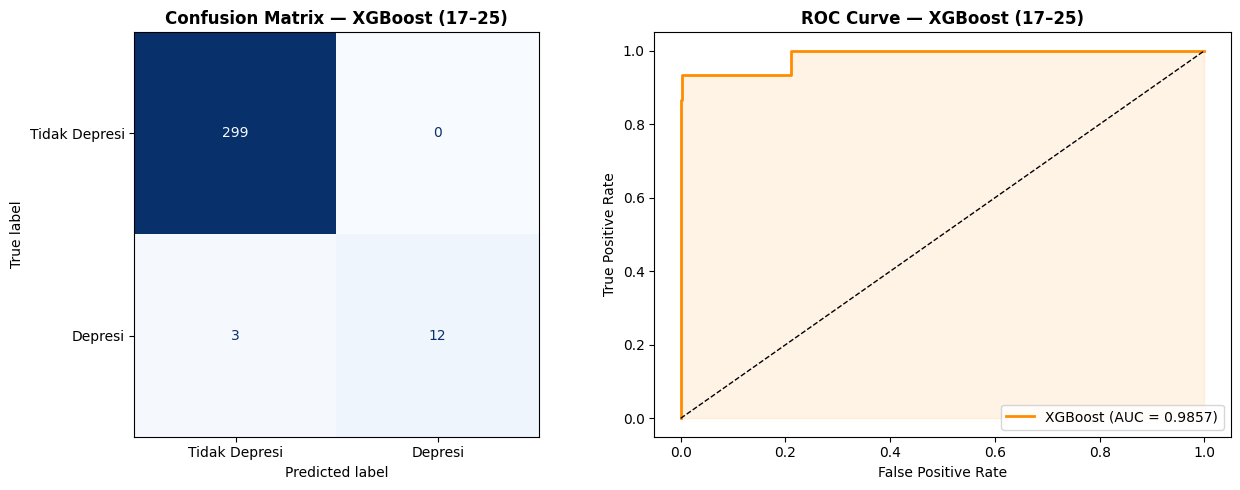

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Tidak Depresi', 'Depresi']
).plot(cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title('Confusion Matrix — XGBoost (17–25)', fontweight='bold')

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'XGBoost (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='darkorange')
axes[1].set_title('ROC Curve — XGBoost (17–25)', fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')

plt.tight_layout()
plt.show()

---
## 🌟 Cell 10 — Feature Importance

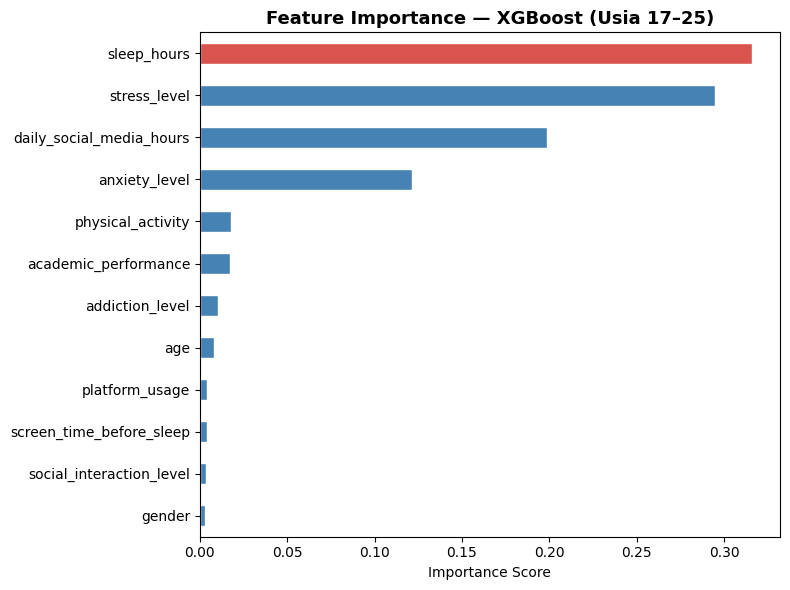

--- Ranking Fitur Terpenting ---
   1. sleep_hours                    : 0.3163
   2. stress_level                   : 0.2949
   3. daily_social_media_hours       : 0.1984
   4. anxiety_level                  : 0.1215
   5. physical_activity              : 0.0180
   6. academic_performance           : 0.0174
   7. addiction_level                : 0.0102
   8. age                            : 0.0083
   9. platform_usage                 : 0.0044
  10. screen_time_before_sleep       : 0.0040
  11. social_interaction_level       : 0.0036
  12. gender                         : 0.0029


In [12]:
feat_imp = pd.Series(
    xgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ['#d9534f' if v == feat_imp.max() else 'steelblue' for v in feat_imp.values]
feat_imp.plot(kind='barh', color=colors, edgecolor='white')
plt.title('Feature Importance — XGBoost (Usia 17–25)', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('--- Ranking Fitur Terpenting ---')
for rank, (feat, score) in enumerate(feat_imp.sort_values(ascending=False).items(), 1):
    print(f'  {rank:2}. {feat:<30} : {score:.4f}')

---
## 🔄 Cell 11 — Cross Validation (5-Fold)

     CROSS VALIDATION (5-Fold Stratified)
  Accuracy per fold : ['0.9934', '0.9934', '0.9836', '0.9967', '0.9901']
  Mean Accuracy     : 0.9915 ± 0.0044

  AUC per fold      : ['0.9972', '0.9905', '0.9950', '1.0000', '0.9625']
  Mean AUC          : 0.9890 ± 0.0136


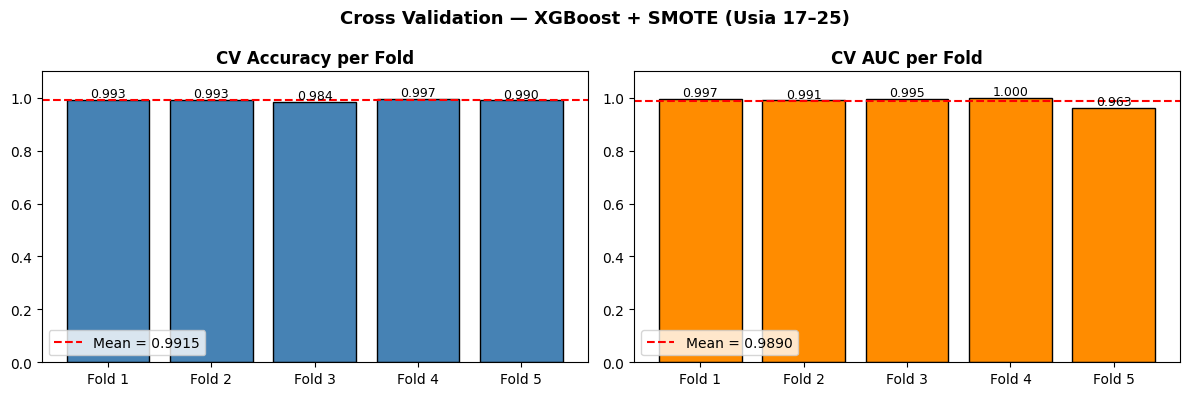

In [13]:
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', xgb.XGBClassifier(
        n_estimators=200, max_depth=5, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        eval_metric='logloss', random_state=42, verbosity=0
    ))
])

cv     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_acc = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')
cv_auc = cross_val_score(pipeline, X, y, cv=cv, scoring='roc_auc')

print('=' * 45)
print('     CROSS VALIDATION (5-Fold Stratified)')
print('=' * 45)
print(f'  Accuracy per fold : {[f"{s:.4f}" for s in cv_acc]}')
print(f'  Mean Accuracy     : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print()
print(f'  AUC per fold      : {[f"{s:.4f}" for s in cv_auc]}')
print(f'  Mean AUC          : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print('=' * 45)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar([f'Fold {i+1}' for i in range(5)], cv_acc,
            color='steelblue', edgecolor='black')
axes[0].axhline(cv_acc.mean(), color='red', linestyle='--',
                label=f'Mean = {cv_acc.mean():.4f}')
axes[0].set_title('CV Accuracy per Fold', fontweight='bold')
axes[0].set_ylim(0, 1.1)
axes[0].legend()
for i, v in enumerate(cv_acc):
    axes[0].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

axes[1].bar([f'Fold {i+1}' for i in range(5)], cv_auc,
            color='darkorange', edgecolor='black')
axes[1].axhline(cv_auc.mean(), color='red', linestyle='--',
                label=f'Mean = {cv_auc.mean():.4f}')
axes[1].set_title('CV AUC per Fold', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].legend()
for i, v in enumerate(cv_auc):
    axes[1].text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=9)

plt.suptitle('Cross Validation — XGBoost + SMOTE (Usia 17–25)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 💾 Cell 12 — Simpan Model ke JSON

In [ ]:
import os

# Buat folder models jika belum ada
model_dir  = 'models'
os.makedirs(model_dir, exist_ok=True)

model_path = os.path.join(model_dir, 'xgboost_model_new.json')

# Simpan model
xgb_model.save_model(model_path)

# Verifikasi file tersimpan
file_size = os.path.getsize(model_path) / 1024

print('=' * 50)
print('  ✅ MODEL BERHASIL DISIMPAN!')
print('=' * 50)
print(f'  Path        : {os.path.abspath(model_path)}')
print(f'  Ukuran file : {file_size:.1f} KB')
print(f'  Format      : JSON (XGBoost native)')
print(f'  Range usia  : 17 - 25 tahun')
print('=' * 50)
print()
print('  Encoding yang digunakan (penting untuk website):')
for col, mapping in encoding_map.items():
    print(f'  {col}: {mapping}')

  ✅ MODEL BERHASIL DISIMPAN!
  Path        : d:\code\depression_calc\models\xgboost_model.json
  Ukuran file : 176.3 KB
  Format      : JSON (XGBoost native)
  Range usia  : 17 - 25 tahun

  Encoding yang digunakan (penting untuk website):
  gender: {'female': 0, 'male': 1}
  platform_usage: {'Both': 0, 'Instagram': 1, 'TikTok': 2}
  social_interaction_level: {'high': 0, 'low': 1, 'medium': 2}


---
## 📋 Cell 13 — Ringkasan Akhir

In [15]:
top_feat = pd.Series(xgb_model.feature_importances_, index=X.columns).idxmax()

print('=' * 52)
print('    RINGKASAN HASIL — XGBoost + SMOTE (17–25)')
print('=' * 52)
print(f'  Dataset              : Mental Health (expanded)')
print(f'  Range usia           : 17 - 25 tahun')
print(f'  Total sampel         : {len(df)}')
print(f'     - Original (17–19): {len(df_17_19)}')
print(f'     - Sintetis (20–25): {len(df_synthetic)}')
print(f'  Fitur                : {X.shape[1]}')
print(f'  Algoritma            : XGBoost')
print(f'  Handling Imbalance   : SMOTE')
print()
print(f'  [TEST SET]')
print(f'  Accuracy             : {acc:.4f} ({acc*100:.2f}%)')
print(f'  ROC-AUC              : {auc:.4f}')
print()
print(f'  [CROSS VALIDATION - 5 Fold]')
print(f'  Mean Accuracy        : {cv_acc.mean():.4f} ± {cv_acc.std():.4f}')
print(f'  Mean AUC             : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print()
print(f'  Fitur paling penting : {top_feat}')
print(f'  Model disimpan di    : models/xgboost_model.json')
print('=' * 52)

    RINGKASAN HASIL — XGBoost + SMOTE (17–25)
  Dataset              : Mental Health (expanded)
  Range usia           : 17 - 25 tahun
  Total sampel         : 1524
     - Original (17–19): 504
     - Sintetis (20–25): 1020
  Fitur                : 12
  Algoritma            : XGBoost
  Handling Imbalance   : SMOTE

  [TEST SET]
  Accuracy             : 0.9904 (99.04%)
  ROC-AUC              : 0.9857

  [CROSS VALIDATION - 5 Fold]
  Mean Accuracy        : 0.9915 ± 0.0044
  Mean AUC             : 0.9890 ± 0.0136

  Fitur paling penting : sleep_hours
  Model disimpan di    : models/xgboost_model.json
